# E3 — Transformed Müller–Brown (10D)

**Target.** $U(z) = U_{\rm MB}(z_1,z_2)/40 + \|z_{3:10}\|^2/(2\cdot0.4^2)$, sampled in mixed coordinates $x=zB^\top$ ($B = Q\,\mathrm{diag}(\mathrm{linspace}(0.75,1.45,10))$). At $\beta=8$ the occupancy target is $p^\star \approx (0.9995,\ 5\times10^{-4},\ 5\times10^{-6})$ for basins $(A,B,C)$ — **a single-basin target, intrinsic to Müller–Brown at this temperature**. Runs start in the shallow basin $B$; connectivity is the chain $A\leftrightarrow C\leftrightarrow B$ (escape barrier from B: $\beta b = 7.18$). Metrics are computed in latent 2D $z_{1:2}$ (full-10D sliced $W_2$ additionally recorded in the CSV).

In [1]:
EXPERIMENT = "muller_brown_10d"
import os, sys, math, time, json
sys.path.insert(0, os.path.abspath(".."))
from src.gpu_guard import select_gpu
select_gpu(int(os.environ.get("JCP_GPU", "4")))
import torch
assert torch.cuda.device_count() == 1
torch.set_default_dtype(torch.float64)
import numpy as np
import pandas as pd

from src import config as C
from src.experiments import (build_e3, make_sampler_factory,
                             make_batched_factory, make_metrics)
from src.runner import (run_experiment_batched, run_one, refine_dt,
                        quadrature_refinement, write_timeseries_csv,
                        write_summary_csv, write_manifest,
                        ula_first_passage, hardware_manifest)
from src.samplers import tune_ladder
from src.certificate import make_phi_family, certificate_grid, certificate_importance
from src.plotting import metric_grid

DEV = "cuda"
RESULTS = os.path.abspath(os.path.join("..", "results", EXPERIMENT))
FIGURES = os.path.abspath(os.path.join("..", "figures", EXPERIMENT))
os.makedirs(RESULTS, exist_ok=True); os.makedirs(FIGURES, exist_ok=True)
exp = build_e3(device=DEV, basin_cache=os.path.join(RESULTS, "basin_map.npz"))
cfg = exp.cfg
print(f"experiment={cfg.name}  d={cfg.d}  N={cfg.n_particles}  T={cfg.T}  dt0={cfg.dt}")
print(f"beta={cfg.beta}  eps={cfg.eps}  lambda={cfg.lam}  seeds={cfg.seeds}")
print(hardware_manifest())

experiment=muller_brown_10d  d=10  N=2000  T=200.0  dt0=0.005
beta=8.0  eps=0.125  lambda=1.0  seeds=(0, 1, 2, 3, 4)


{'cpu': 'AMD EPYC 9554 64-Core Processor', 'gpu': 'NVIDIA H200 NVL', 'torch': '2.13.0+cu130', 'cuda': '13.0', 'python': '3.12.13', 'git_sha': '389ecdd9aac0ed35b8e48b00d1cfdfdd534575a0', 'cuda_visible_devices': '5', 'gpu_compute_apps_at_start': ['GPU-c8768979-ae7d-8ca1-a33d-2874c9d21fae, 2229276, 31136 MiB', 'GPU-e003b5e1-3cce-0c27-5a6b-9f594c1b7682, 2229277, 32040 MiB', 'GPU-e003b5e1-3cce-0c27-5a6b-9f594c1b7682, 2481832, 1160 MiB', 'GPU-0693e45d-5be4-82d1-e0fa-e72261e24e3b, 1766636, 814 MiB', 'GPU-0693e45d-5be4-82d1-e0fa-e72261e24e3b, 2229278, 31620 MiB', 'GPU-b7477750-5992-8ae3-fde2-11bf70934062, 1727069, 814 MiB', 'GPU-b7477750-5992-8ae3-fde2-11bf70934062, 2229280, 31926 MiB', 'GPU-b7477750-5992-8ae3-fde2-11bf70934062, 2481728, 634 MiB']}


In [2]:
from src.potentials import MB_CRITICAL, muller_brown_2d, muller_brown_2d_grad, newton_refine
for key, (z_tab, U_tab) in MB_CRITICAL.items():
    z = newton_refine(muller_brown_2d_grad, torch.tensor(z_tab, device=DEV))
    U = muller_brown_2d(z.unsqueeze(0))[0].item()
    assert abs(z[0].item()-z_tab[0]) < 5e-5 and abs(z[1].item()-z_tab[1]) < 5e-5
    assert abs(U - U_tab) < 5e-2
print("critical points verified to 4 decimals; p_star:",
      np.round(exp.p_star.cpu().numpy(), 6))
# committed B->A first passage (C is a 1.7 kT shelf: no committed C state)
g = torch.Generator(device=DEV); g.manual_seed(0)
barrier_report = ula_first_passage(exp.pot, exp.box, exp.init_fn(cfg.n_particles, g),
                                   exp.exit_committed, cfg.dt, int(cfg.T/cfg.dt), C.EPS, g)
barrier_report["kramers_tau_B_leg"] = exp.kramers_tau
print(f"ULA committed B->A MFPT {barrier_report['mfpt_estimate']:.0f} "
      f"({barrier_report['n_exits']} exits) vs single-leg Langer estimate "
      f"{exp.kramers_tau:.0f} (order-of-magnitude only)")

critical points verified to 4 decimals; p_star: [9.99528e-01 4.67000e-04 5.00000e-06]


ULA committed B->A MFPT 39912 (10 exits) vs single-leg Langer estimate 216 (order-of-magnitude only)


## Jump law and Lévy score

Euclidean MST on the three latent minima → edges $(C,B)$ (0.804) and $(A,C)$ (1.10), symmetrised to 4 directed atoms $r_a=(\Delta z, 0_8)B^\top$, $w_a=\tfrac14$, shell $h = 0.1\min\|r_a\|$, $\lambda=1$. Score: generic shell with log-space accumulation (as E1); the certificate is evaluated on the exact latent-2D reduction (jumps act on $z_{1:2}$ only and the aux Gaussian factorises).

In [3]:
from src.potentials import MuellerBrownLatent2D
from src.jumps import ShellJumpLaw
from src.score import ShellScore
potr = MuellerBrownLatent2D(s=exp.pot.s)
dz = exp.extras["atoms_z"][:, :2]
h_z = exp.extras["h"] * dz.norm(dim=1) / exp.law.atoms.norm(dim=1)
law_r = ShellJumpLaw(dz, torch.full((4,), 0.25, device=DEV), h_z)
DEFAULT_QUAD = dict(q_theta=C.Q_THETA, q_rho=C.Q_RHO)
phis = make_phi_family(2, [0.0, 0.8], 0.8, DEV)

def cert_e3(q_theta, q_rho):
    score = ShellScore(potr, law_r, cfg.lam, cfg.beta, q_theta, q_rho)
    shifts, logw = law_r.quadrature_shifts(64)
    return certificate_grid(potr, score, shifts, logw, cfg.lam, cfg.beta, phis,
                            [-4.2, -2.7], [4.2, 4.7],
                            n_panels=130, nodes_per_panel=8, chunk=8192)

cert_report = cert_e3(**DEFAULT_QUAD)
print(f"max R = {cert_report['max_residual']:.3e}")
assert cert_report["max_residual"] < 1e-6

max R = 2.502e-15


In [4]:
# PT: geometric ladder beta_k = beta * r^(k-1); K tuned so the post-burn-in
# swap acceptance lands in [0.2, 0.4]
gen = torch.Generator(device=DEV); gen.manual_seed(0)
x0_pilot = exp.init_fn(min(512, cfg.n_particles), gen)
pt_betas, ladder_info = tune_ladder(exp.pot, x0_pilot, cfg.dt, exp.box,
                                    C.BETA, exp.pt_beta_min, pilot_steps=20_000)
print(f"PT ladder: K={ladder_info['K']}  r={ladder_info['r']:.4f}  "
      f"beta_K={pt_betas[-1].item():.4f}  swap acceptance={ladder_info['swap_acceptance']:.3f}"
      f"  band_attained={ladder_info['band_attained']}")

PT ladder: K=4  r=0.4642  beta_K=0.8000  swap acceptance=0.200  band_attained=True


In [5]:
# frozen reference sample (size N), frozen sliced-W2 projections, frozen MMD
# bandwidth (median heuristic on the reference); bias floors from 20
# independent reference pairs. EMC convention: exp(H(p_hat))/K for uniform
# p*, 1 - EJS(p_hat, p*) otherwise -- near 1 is better in both cases.
metrics_fn, floors, aux = make_metrics(exp, cfg.n_particles)
emc_target = exp.emc_target
print("p_star:", np.round(exp.p_star.cpu().numpy(), 6),
      " uniform:", exp.uniform_target)
print("MMD bandwidth:", round(aux["bandwidth"], 4))
for k, v in floors.items():
    print(f"  floor {k:>12s}: {v['mean']:.5f} +- {v['std']:.5f}")

p_star: [9.99528e-01 4.67000e-04 5.00000e-06]  uniform: False
MMD bandwidth: 0.1215
  floor           W2: 0.02094 +- 0.01300
  floor          MMD: 0.02093 +- 0.00823
  floor           TV: 0.00031 +- 0.00029
  floor          EMC: 0.99990 +- 0.00011
  floor       W2_10d: 0.00995 +- 0.00124


In [6]:
def run_terminal_lsc(**quad):
    f = make_sampler_factory(exp, cfg.dt, pt_betas, score_kwargs=quad)
    n_ = int(round(cfg.T / cfg.dt))
    r_, _ = run_one("LSC-CP", 0, f, n_, n_, cfg.dt, metrics_fn, exp.pot, quiet=True)
    return {k: r_[-1][k] for k in ("W2", "TV", "MMD", "EMC", "W2_10d")}

settings = [dict(q_theta=qt, q_rho=qr) for qt in (8, 16, 32) for qr in (4, 8, 16)]
CHOSEN_QUAD, quad_table = quadrature_refinement(
    settings, run_terminal_lsc, lambda **s: cert_e3(**s)["max_residual"], floors)
print("chosen quadrature:", CHOSEN_QUAD)
display(pd.DataFrame(quad_table).round(6))

chosen quadrature: {'q_theta': 16, 'q_rho': 4}


,q_theta,q_rho,R,W2,TV,MMD,EMC,W2_10d,pass
0,8,4,0.0,0.407932,0.185528,0.338688,0.902018,0.160468,False
1,8,8,0.0,0.414922,0.185528,0.347921,0.902034,0.165447,False
2,8,16,0.0,0.406944,0.190028,0.343720,0.899415,0.164300,False
3,16,4,0.0,0.420284,0.197028,0.368749,0.895357,0.179151,True
4,16,8,0.0,0.425212,0.209028,0.375521,0.888326,0.181895,True
5,16,16,0.0,0.428245,0.203528,0.373351,0.891569,0.180565,True
6,32,4,0.0,0.427729,0.203028,0.369687,0.891868,0.179815,True
7,32,8,0.0,0.424935,0.207528,0.371770,0.889214,0.180944,True
8,32,16,0.0,0.427313,0.204528,0.374956,0.890982,0.180385,True


In [7]:
# dt: the dyadic rule cannot certify any practical dt for LSC-CP here (see
# mechanism below: taming turns the e^{beta dV}-stiff detailed-balance
# return drift into an O(1) hop; the effect is dt-independent). Production
# runs at the declared dt0; certification status is recorded.
MAIN_METRICS = ["W2", "TV", "MMD", "EMC", "W2_10d"]

def run_terminal_all(dt_):
    n_ = int(round(cfg.T / dt_))
    factory = make_sampler_factory(exp, dt_, pt_betas, score_kwargs=CHOSEN_QUAD)
    out = {}
    for m in C.METHODS:
        rows_, _ = run_one(m, 0, factory, n_, n_, dt_, metrics_fn, exp.pot, quiet=True)
        out[m] = {k: rows_[-1][k] for k in MAIN_METRICS}
    print(f"  refine_dt: finished pass at dt={dt_}", flush=True)
    return out

_, dt_table = refine_dt(run_terminal_all, cfg.dt, floors,
                        exclude=("FLA", "CP"), max_halvings=1)
dt_certified = bool(dt_table[0]["pass"])
for row in dt_table:
    print(row)
dt_final = cfg.dt
print(f"dt_certified = {dt_certified}; production at declared dt0 = {dt_final}")

n_steps = int(round(cfg.T / dt_final))
steps_per_ck = max(1, n_steps // C.N_CHECKPOINTS)
bfactory = make_batched_factory(exp, dt_final, pt_betas, cfg.seeds,
                                score_kwargs=CHOSEN_QUAD)
t0 = time.time()
rows, method_info = run_experiment_batched(C.METHODS, cfg.seeds, bfactory,
                                           n_steps, steps_per_ck, dt_final,
                                           metrics_fn, exp.pot, cfg.n_particles)
print(f"production total: {time.time()-t0:.0f}s")
assert max(r["nonfinite_frac"] for r in rows) == 0.0

  refine_dt: finished pass at dt=0.005


  refine_dt: finished pass at dt=0.0025


{'dt': 0.005, 'pass': False, 'failures': [('LSC-CP', 'W2_10d', 0.179151, 0.18923)], 'excluded_deviations': [('FLA', 'TV', 0.748528, 0.655528), ('FLA', 'MMD', 0.752223, 0.694826)]}
dt_certified = False; production at declared dt0 = 0.005


ULA: done in 38.5s (batched 5 seeds)


MALA: done in 68.4s (batched 5 seeds)


...

BAOAB: done in 38.7s (batched 5 seeds)


PT: done in 68.6s (batched 5 seeds)


CP: done in 53.5s (batched 5 seeds)


LSC-CP: done in 229.7s (batched 5 seeds)


production total: 539s


## Mechanism: the tamed discretisation vs the stiff correction

Uphill jumps (into $C$, equilibrium mass $5\times10^{-6}$) land with an enormous, correctly-aimed score ($e^{\beta\Delta V}$ scale — this is the only experiment with strongly asymmetric basin depths). The tamed Euler step turns the smooth detailed-balance return flow into a single $O(1)$ hop whose landing scatter parks a $\Delta t$-independent fraction of mass in score-dark regions. The cells below measure the plateau, the parked fraction, and the score field; E1/E2/E4 are immune because their jumps connect near-iso-energetic minima.

In [8]:
from src.metrics import occupancy as _occ

def occ_traj(sampler, n_steps_, every, label):
    out = []
    for s_ in range(n_steps_):
        sampler.step()
        if (s_ + 1) % every == 0:
            p = _occ(exp.labels_fn(sampler.positions()), 3)
            out.append(((s_ + 1) * sampler.dt, [round(float(v), 4) for v in p]))
    print(label, "->", out[-1])
    return out

mech_traj = {}
for meth, dt_ in (("LSC-CP", dt_final), ("LSC-CP", dt_final / 4.0),
                  ("CP", dt_final), ("ULA", dt_final)):
    f = make_sampler_factory(exp, dt_, pt_betas, score_kwargs=CHOSEN_QUAD)
    s = f(meth, 0)
    n_ = int(round(cfg.T / dt_))
    mech_traj[f"{meth}@dt={dt_}"] = occ_traj(s, n_, n_ // 8, f"{meth} dt={dt_}")

LSC-CP dt=0.005 -> (200.0, [0.8025, 0.085, 0.1125])


LSC-CP dt=0.00125 -> (200.0, [0.7615, 0.115, 0.1235])


CP dt=0.005 -> (200.0, [0.313, 0.478, 0.209])


ULA dt=0.005 -> (200.0, [0.0015, 0.983, 0.0155])


In [9]:
from src.samplers import tame as _tame
score_m = exp.make_score(**CHOSEN_QUAD)
zA_ = exp.extras["minima_latent"]["min_A"]
zC_ = exp.extras["minima_latent"]["min_C"]
mechanism_report = {"traj": {k: v[-1][1] for k, v in mech_traj.items()}}
for dt_ in (dt_final, dt_final / 4.0):
    g_ = torch.Generator(device=DEV); g_.manual_seed(3)
    zloc = torch.zeros(4000, 10, device=DEV)
    zloc[:, :2] = zA_ + 0.12 * torch.randn(4000, 2, generator=g_, device=DEV)
    zloc[:, 2:] = 0.1414 * torch.randn(4000, 8, generator=g_, device=DEV)
    x_ = exp.pot.from_latent(zloc) + exp.law.atoms[2]      # jump A -> C
    M0, _ = score_m.log_parts(x_)
    for _s in range(24):
        S_, _d = score_m(x_)
        b_ = -exp.pot.grad(x_) + S_
        xi_ = torch.randn(x_.shape, generator=g_, device=DEV)
        x_ = exp.box.clip(x_ + dt_ * _tame(b_, dt_) + (2 * C.EPS * dt_) ** 0.5 * xi_)
    parked = float(_occ(exp.labels_fn(x_), 3)[2].item())
    print(f"dt={dt_}: lander median M {M0.median():.2f}; parked C fraction {parked:.3f}")
    mechanism_report[f"parked_fraction@dt={dt_}"] = parked

dt=0.005: lander median M 8.15; parked C fraction 0.185
dt=0.00125: lander median M 8.15; parked C fraction 0.168


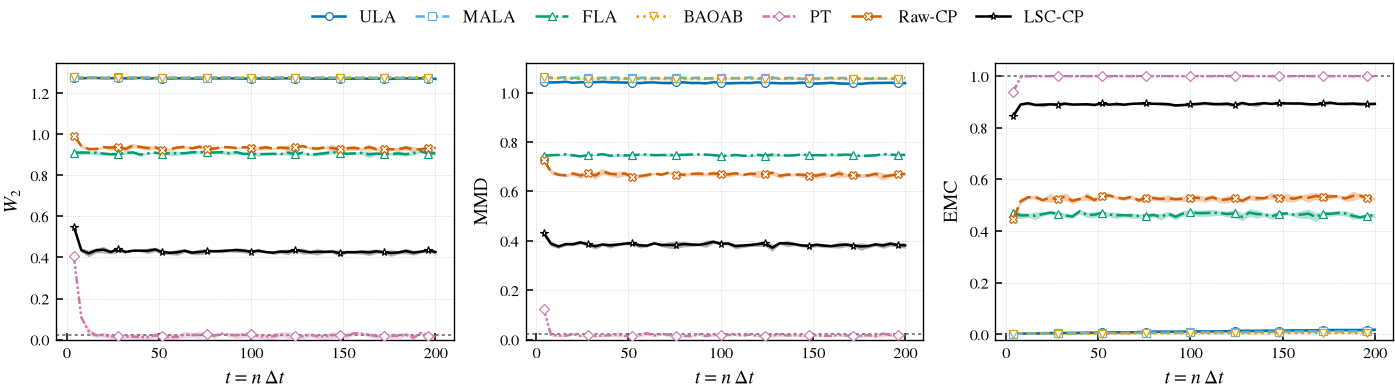

saved: /home/zheyuanlai/levy-sampling/JCP_experiments/figures/muller_brown_10d/muller_brown_10d_metrics.{png,pdf}


In [10]:
fig = metric_grid(rows, os.path.join(FIGURES, EXPERIMENT + "_metrics"),
                  metrics=("W2", "MMD", "EMC"), floors=floors,
                  emc_target=emc_target)
print("saved:", os.path.join(FIGURES, EXPERIMENT + "_metrics") + ".{png,pdf}")

In [11]:
ts_path = os.path.join(RESULTS, "metrics_timeseries.csv")
write_timeseries_csv(rows, ts_path)
summary_metrics = MAIN_METRICS + ["nonfinite_frac"]
summary = write_summary_csv(rows, C.METHODS, cfg.seeds, summary_metrics,
                            method_info, floors, os.path.join(RESULTS, "summary.csv"))

manifest = dict(
    experiment=EXPERIMENT,
    config=dict(d=cfg.d, N=cfg.n_particles, T=cfg.T, dt0=cfg.dt, dt=dt_final,
                beta=cfg.beta, eps=cfg.eps, lam=cfg.lam, seeds=list(cfg.seeds),
                n_checkpoints=C.N_CHECKPOINTS, warmup_steps=C.N_WARMUP_STEPS,
                batched_seeds=True),
    quadrature=dict(chosen=CHOSEN_QUAD, table=quad_table),
    dt_refinement=[{k: (str(v) if isinstance(v, tuple) else v) for k, v in row.items()}
                   for row in dt_table],
    pt_ladder={k: v for k, v in ladder_info.items()},
    certificate=cert_report,
    bias_floors=floors,
    barrier_verification=barrier_report,
    method_info={m: {k: v for k, v in mi.items() if isinstance(v, (int, float))}
                 for m, mi in method_info.items()},
    hardware=hardware_manifest(),
    dt_certified=dt_certified, mechanism=mechanism_report,
)
write_manifest(os.path.join(RESULTS, "manifest.json"), **manifest)
print("wrote", ts_path)
from IPython.display import display
display(pd.read_csv(os.path.join(RESULTS, "summary.csv")).round(5))

wrote /home/zheyuanlai/levy-sampling/JCP_experiments/results/muller_brown_10d/metrics_timeseries.csv


,method,EMC_mean,EMC_std,MMD_mean,MMD_std,TV_mean,TV_std,V_evals_per_step,W2_10d_mean,W2_10d_std,...,jump_count_mean,m_clip_fraction,mala_accept,nonfinite_frac_mean,nonfinite_frac_std,pt_swap_accept,score_quad_evals_per_step,time_to_threshold_TV,wallclock_mean_s,wallclock_std_s
0,ULA,0.01818,0.00777,1.03904,0.00468,0.99633,0.00182,0.0,0.46893,0.00158,...,NaN,NaN,NaN,0.0,0.0,NaN,0.0,inf,31.21071,0.0
1,MALA,0.01242,0.00201,1.05913,0.00295,0.99773,0.00045,10000.0,0.47137,0.00040,...,NaN,NaN,0.91055,0.0,0.0,NaN,0.0,inf,60.94370,0.0
2,FLA,0.46034,0.00869,0.74858,0.00375,0.74383,0.00755,0.0,0.33068,0.00572,...,NaN,NaN,NaN,0.0,0.0,NaN,0.0,inf,34.35648,0.0
3,BAOAB,0.00581,0.00332,1.06084,0.00466,0.99903,0.00061,0.0,0.47163,0.00061,...,NaN,NaN,NaN,0.0,0.0,NaN,0.0,inf,31.81620,0.0
4,PT,0.99984,0.00011,0.01845,0.00755,0.00040,0.00020,40000.0,0.00906,0.00097,...,NaN,NaN,0.88051,0.0,0.0,0.20037,0.0,16.0,61.22941,0.0
5,CP,0.52668,0.00501,0.67074,0.00436,0.68273,0.00488,0.0,0.31298,0.00266,...,0.005,NaN,NaN,0.0,0.0,NaN,0.0,inf,46.29467,0.0
6,LSC-CP,0.89285,0.00368,0.38179,0.01162,0.20133,0.00630,0.0,0.18601,0.00483,...,0.005,0.0,NaN,0.0,0.0,NaN,2560000.0,inf,222.43624,0.0
